# Language Detection Model

This project focuses on Language Detection, which is a multi-class classification task in the field of NLP. Our goal is to train a model to automatically identify/predict the language of a given text.

While identifying a language might seems obvious to us human beings, it is a complex challenge for a computer. The difficulty lies in the fact that many languages share the exact same alphabet. For example, English, French, and Spanish all use Latin letters, while several Middle Eastern and Asian languages might use similar-looking characters. A machine cannot "read" like we do. instead, it must uncover hidden patterns and statistical fingerprints, such as the frequency of specific character combinations (n-grams) or unique word structures that define each language.

We are using a [Kaggle dataset that contains 10,000 sentences across 17 different languages](https://www.kaggle.com/datasets/basilb2s/language-detection), including English, Arabic, Spanish, and others. To evaluate our success, we will use the Macro-Average F1 score, which ensures that the model is accurate across all languages, regardless of how many sentences they have in the dataset.

## Project Members

| Name | Last 4 Digits of ID |
| :--- | :--- |
| Almog S | 5890 |
| Eliad B | 6279 |

## AI Prompts

We used Gemini to improve code efficiency with the following prompts:
1. Help us find a relevant dataset for language detection ML model.
2. How can we optimize our evaluation algorithm? (running time, complexity, etc.)
3. Is my KNN class implementation optimal?
4. How to calculate macro-average-f1 score with K-Fold CV with sklearn?

## Import Dependencies

In [1]:
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

text_col = 'Text'
label_col = 'Language'

def load_dataset(file_path):
    return pd.read_csv(file_path, encoding='utf-8')

def view_features(raw, vectorized_data, row_idx):
    row = vectorized_data[row_idx]
    nonzero_indices = row.indices # if we wont filter the data, we'll see most of the columns are filled with 0.0
    tfidf_values = row.data
    
    all_feature_names = vectorizer.get_feature_names_out()
    nonzero_feature_names = [all_feature_names[i] for i in nonzero_indices]
    table = pd.DataFrame([tfidf_values], columns=nonzero_feature_names)
    display(table)

## Loading the dataset

Our dataset is stored in a CSV file that contains 2 columns: the **text**s and its corresponding **language** label. A DataFrame is the perfect tool for organizing the data and the labels into a clean, tabular structure that is easy to manipulate.

In [2]:
df = load_dataset('dataset.csv')
print(f"{df.shape[0]} sentences have been processed.")
df.head()

10337 sentences have been processed.


,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


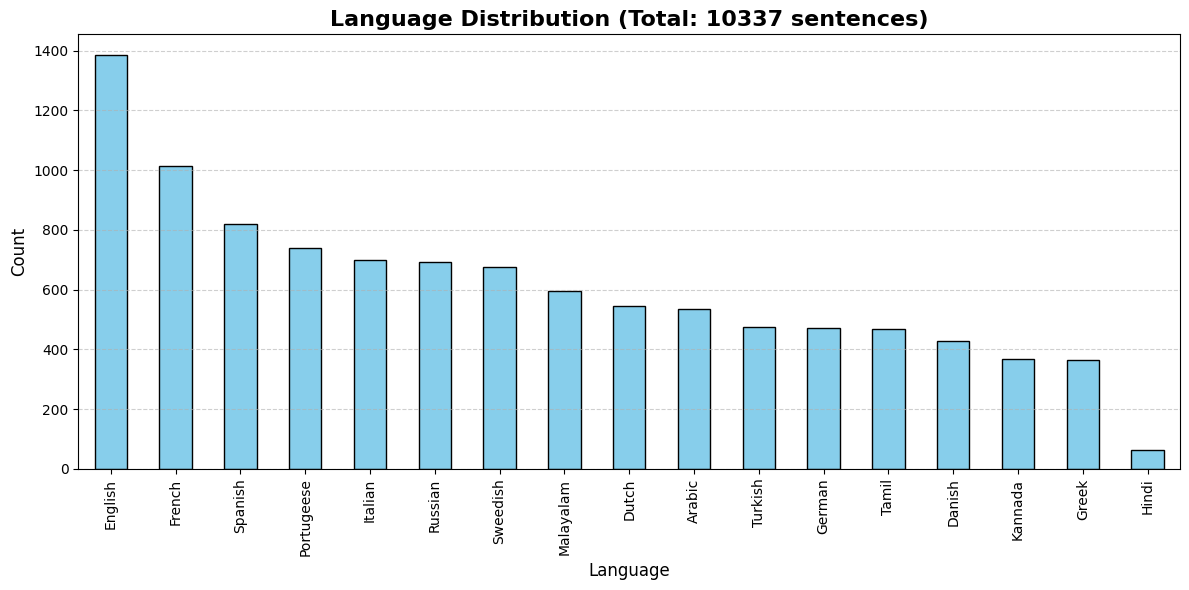

In [3]:
language_counts = df[label_col].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
language_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Language Distribution (Total: {} sentences)'.format(df.shape[0]), fontsize=16, fontweight='bold')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

## Data Splitting

First, we split the data into train set and test set. We chose to split the data into 80% training and 20% testing.

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(df[text_col], df[label_col], test_size=0.2, random_state=42)

train_preview = pd.concat([X_train_raw, y_train], axis=1)
train_preview.columns = [text_col, label_col]

test_preview = pd.concat([X_test_raw, y_test], axis=1)
test_preview.columns = [text_col, label_col]

print("### Table 1: Train Set Snapshot (First 5 Rows)")
display(train_preview.head())
print("### Table 2: Test Set Snapshot (First 5 Rows)")
display(test_preview.head())

### Table 1: Train Set Snapshot (First 5 Rows)


,Text,Language
5967,τώρα αργότερα η Μέλι και ο Τέρι έσπασαν αντίο ...,Greek
3570,Améliorez-le ou discutez-en.,French
7607,"non ne vale la pena, personalmente amo la fras...",Italian
3080,tente copiar minha pronúncia exatamente inclui...,Portugeese
828,If the complexity of the model is increased in...,English


### Table 2: Test Set Snapshot (First 5 Rows)


,Text,Language
6662,"И с этими словами она села в его карету, и, да...",Russian
7362,Sistemi di tipo probabilistico erano invasi di...,Italian
765,Machine learning involves computers discoverin...,English
6192,Несколько языковых версий опубликовали подборк...,Russian
562,"[225] In May 2014, Wikimedia Foundation named ...",English


## Feature Engineering

In this step, we transform the raw text into a numerical format that the machine learning algorithm can understand. We use the **TF-IDF Vectorizer with Character N-grams** (ranging from 1 to 3 characters): Instead of looking at complete words, the model breaks down each sentence into small sequences of single letters, pairs, and triplets. This is very effective for language detection because every language has a unique statistical "fingerprint" based on how often specific character combinations appear. This method allows the model to differentiate between languages that share the same alphabet and stay accurate even when there are typos or unfamiliar words.

**How does TF-IDF work?**

The value in each cell is calculated using this formula:

$$Score = TF \times IDF$$

Where:

$$TF = \frac{\text{Number of times the sequence appears in the row}}{\text{Total number of sequences in that row}}$$

$$IDF = \log \left( \frac{\text{Total number of rows in the DataFrame}}{\text{Number of rows containing the sequence}} \right)$$

In other words, $TF$ indicates how many times a specific letter sequence appears in a single sentence, while $IDF$ indicates how rare this sequence is across the entire dataset.

**The higher the score, the more important that character sequence is for identifying the language.**

In [5]:
# analyzer='char' tells the model to look at characters, not words.
# ngram_range=(1, 3) looks at single letters, pairs, and triplets.
# norm='l2' will make our data normalized
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4), norm='l2')
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

print(X_train.shape)
print(X_test.shape)

(8269, 205625)
(2068, 205625)


Below are examples of the non-zero features of 2 sentences.

In [6]:
for i in [0, 1, 2]:
    print(f"Train example {i}: '{X_train_raw.iloc[i]}'")
    view_features(X_train_raw, X_train, i)

for i in [0, 1, 2]:
    print(f"Test example {i}: '{X_test_raw.iloc[i]}'")
    view_features(X_test_raw, X_test, i)

Train example 0: 'τώρα αργότερα η Μέλι και ο Τέρι έσπασαν αντίο στον παλιό τους φίλο και πήγαν να χαμογελούν ο ένας στον άλλο κρυφά εκείνο το βράδυ, τόσο μητέρα όσο και κόρη.'


,τώ,ώρ,ρα,α,α,αρ,ργ,γό,ότ,τε,...,έρα,ρα ό,α όσ,όσο,σο κ,αι κ,ι κό,κόρ,κόρη,όρη.
0,0.036452,0.038795,0.091203,0.103228,0.053389,0.030579,0.038536,0.041907,0.030285,0.027973,...,0.041462,0.048017,0.048017,0.046776,0.044905,0.039652,0.051871,0.044905,0.044905,0.051871


Train example 1: 'Améliorez-le ou discutez-en.'


,am,mé,él,li,io,or,re,ez,z-,-l,...,dis,disc,iscu,scut,cute,utez,tez-,ez-e,z-en,-en.
0,0.052965,0.09601,0.105652,0.042445,0.046418,0.038957,0.035189,0.154043,0.233087,0.110127,...,0.078878,0.102724,0.120261,0.147432,0.139179,0.162902,0.170306,0.170306,0.170306,0.170306


Train example 2: 'non ne vale la pena, personalmente amo la frase you rock che significa che sei fantastico.'


...

,а,ан,анг,б,бу,в,в,в в,в е,вн,...,ьно,ью,"ью,","ью,",эт,эти,этим,"ю,","ю,","ю, у"
0,0.02563,0.031775,0.033794,0.022925,0.033316,0.096998,0.045901,0.033316,0.041236,0.035989,...,0.031015,0.032679,0.038563,0.038563,0.023926,0.033094,0.04017,0.032296,0.032296,0.044546


Test example 1: 'Sistemi di tipo probabilistico erano invasi di problemi sia teoretici sia pratici in termini di acquisizione e rappresentazione dei dati[10].'


,a,ac,acq,d,da,dat,de,dei,di,di,...,tip,tipo,ui,uis,uisi,va,vas,zi,zio,zion
0,0.015938,0.038216,0.068063,0.078769,0.027232,0.03989,0.019551,0.05319,0.074587,0.115009,...,0.053355,0.059303,0.029585,0.044299,0.068992,0.026961,0.05606,0.070669,0.085542,0.086362


Test example 2: 'Machine learning involves computers discovering how they can perform tasks without being explicitly programmed to do so.'


,b,be,bei,c,ca,can,co,com,d,di,...,wit,with,xp,xpl,xpli,y,y c,y ca,y p,y pr
0,0.026774,0.036266,0.07074,0.047347,0.039272,0.054108,0.02801,0.035746,0.03874,0.03057,...,0.053759,0.054322,0.057203,0.0695,0.075137,0.06449,0.061004,0.07929,0.062901,0.073326


## Model Training (KNN)

Now that our text is represented as a matrix of numerical vectors (TF-IDF), we can apply the **KNN algorithm**. 

KNN predicts the language of a new sentence by looking at the $k$ most similar sentences in our training data.

The logic of our algorithm implementation is structured as follows:

- We use the **cosine similarity score** to check how similar a test sentence is to the sentences in our training set. The score ranges from [-1,1] and is calculated using the dot product and magnitude:

$$\displaystyle{\text{Cosine similarity} = \cos \left( \theta \right) = \frac{ A \cdot B }{ \left\| A \right\| \cdot \left\| B \right\| } }$$

In this formula, $A$ represents a row vector from $X_{\text{test}}$ and $B$ represents a column vector from $X_{\text{train}}^T$ - the transpose of $X_{\text{train}}$.

Since our data is already L2 normalized by the TF-IDF vectorizer, the magnitude of each vector is 1 ($\|A\| = 1$ and $\|B\| = 1$). This simplifies the formula:

$$\displaystyle{ \text{Cosine similarity} = \frac{ A \cdot B }{ 1 \cdot 1 } = A \cdot B }$$
This means we only need to calculate the **dot product** between the test row and all training rows (using $X_{\text{test}} \cdot X_{\text{train}}^T$). 

So the result of $X_{\text{test}} \cdot X_{\text{train}}^T$ is a matrix where each cell shows the cosine similarity score."

<img src="https://raw.githubusercontent.com/Almoger/Language-Detection-ML/refs/heads/main/Images/dot_product_example.png" alt="error" width="700" height="700">

- For each test sentence (each row), we **sort the similarity scores and pick the $k$ nearest neighbors** - these are the train sentences with the highest similarity scores. 
- We check the labels (languages) of these $k$ neighbors. The language that appears most often among them (based on the majority rule) is chosen as the final prediction for the sentence.

**Note**: We will explore different K-values using Cross-Validation at the [Evaluation](#Evaluation) step to find the optimal hyperparameters.

In [7]:
class KNN(BaseEstimator, ClassifierMixin):
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = np.array(y)

    def predict(self, X_test):
        similarities = X_test.dot(self.X_train.T).toarray() # dot product
        predictions = []
        
        for row in similarities:
            neighbors_indexes = np.argsort(row)[-self.k:] # get k indexes of the highest values (nearest neighbors)
            k_neighbor_labels = self.y_train[neighbors_indexes] # get their labels

            unique_labels, counts = np.unique(k_neighbor_labels, return_counts=True) # count how much times each label appears
            best_label_index = np.argmax(counts) # index of label that appears the most
            best_label = unique_labels[best_label_index] # retreive the label
            predictions.append(best_label)
            
        return np.array(predictions)

## Evaluation - what are the best parameters?

This step will help us answer two key questions:

- How accurate is the model on new text, one that it has never seen before?

- How often does it make mistakes?

We will use the Accuracy score and the Macro F1-score to see the full picture and ensure the model performs well across all 17 languages.

In [8]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np

ngram_options = [(1, 2), (1, 3), (2, 3), (2, 4)]
k_options = [5, 11, 53, 89]

results_list = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_model = None
best_score = -1
best_k = -1
best_vectorizer = None

print(f"Starting Grid Search with manual loops for 5-fold CV...")

for ngram in ngram_options:
    
    for train_index, val_index in kf.split(X_train_raw):
        X_tr, X_val = X_train_raw.iloc[train_index], X_train_raw.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
        
        vectorizer = TfidfVectorizer(analyzer='char', ngram_range=ngram, norm='l2')
        X_tr_vec = vectorizer.fit_transform(X_tr)
        X_val_vec = vectorizer.transform(X_val)
        
        for k in k_options:
            fold_scores = []
            model = KNN(k=k)
            model.fit(X_tr_vec, y_tr)
            preds = model.predict(X_val_vec)
            
            score = f1_score(y_val, preds, average='macro')
            
            fold_scores.append(score)
        
            mean_score = np.mean(fold_scores)
            results_list.append({
                'ngram_range': str(ngram),
                'k': k,
                'mean_f1_macro': mean_score
            })
        
            if mean_score > best_score:
                best_model = model
                best_score = mean_score
                best_k = k
                best_vectorizer = vectorizer

results_df = pd.DataFrame(results_list).sort_values(by='mean_f1_macro', ascending=False)
display(results_df)

best_params = results_df.iloc[0]
print(f"\n✅ Best Configuration: ngram_range={best_params['ngram_range']}, k={best_params['k']}")
print(f"✅ Best Mean F1-Macro: {best_params['mean_f1_macro']:.4f}")

Starting Grid Search with manual loops for 5-fold CV...
Testing Feature Engineering: ngram_range=(1, 2)
Testing Feature Engineering: ngram_range=(1, 3)
Testing Feature Engineering: ngram_range=(2, 3)
Testing Feature Engineering: ngram_range=(2, 4)


,ngram_range,k,mean_f1_macro
50,"(2, 3)",53,0.992370
70,"(2, 4)",53,0.990548
71,"(2, 4)",89,0.990362
62,"(2, 4)",53,0.989291
49,"(2, 3)",11,0.987954
...,...,...,...
6,"(1, 2)",53,0.963770
14,"(1, 2)",53,0.962834
19,"(1, 2)",89,0.959810
15,"(1, 2)",89,0.957986



✅ Best Configuration: ngram_range=(2, 3), k=53
✅ Best Mean F1-Macro: 0.9924


**What can we conclude from this?**

The fact that different k values and different n-gram ranges gave almost the same results shows that our model isn't too sensitive to parameter changes. It means the features we extracted using TF-IDF are very strong "fingerprints" for the languages, and the algorithm can easily identify them.

## Model Testing

Now, we want to check if our model is actually successful. It is important to know if the model truly "learned" how to identify languages or if the results were just a matter of luck. To do this, we will test the model on the Test Set data that the model has never seen before.

In [9]:
from sklearn.metrics import classification_report

X_train = best_vectorizer.fit_transform(X_train_raw)
X_test = best_vectorizer.transform(X_test_raw)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
results_table = pd.DataFrame({'Text': X_test_raw[:20], 'Actual': y_test[:20], 'Predicted': y_pred[:20]})
display(results_table)

report = classification_report(y_test, y_pred)

print("### Classification Report for Language Detection:")
print(report)

,Text,Actual,Predicted
6662,"И с этими словами она села в его карету, и, да...",Russian,Russian
7362,Sistemi di tipo probabilistico erano invasi di...,Italian,Italian
765,Machine learning involves computers discoverin...,English,English
6192,Несколько языковых версий опубликовали подборк...,Russian,Russian
562,"[225] In May 2014, Wikimedia Foundation named ...",English,English
6984,lad mig komme tilbage til dig om det.,Danish,Danish
39,Earth is estimated to have formed 4.54 billion...,English,English
1597,മാതൃക (ഗണിത സമവാക്യത്തിന്റെ മാതൃക) തീരുമാനിച്ച...,Malayalam,Malayalam
6202,В декабре того же года появилось третье издание.,Russian,Russian
10241,"ದುರದೃಷ್ಟವಶಾತ್, ನಾನು ಇಲ್ಲ ಎಂದು ಹೇಳಬೇಕಾಗಿದೆ.",Kannada,Kannada


### Classification Report for Language Detection:
              precision    recall  f1-score   support

      Arabic       1.00      0.99      1.00       106
      Danish       0.97      0.93      0.95        73
       Dutch       0.96      0.96      0.96       111
     English       0.95      1.00      0.97       291
      French       0.99      0.97      0.98       219
      German       0.98      0.96      0.97        93
       Greek       1.00      1.00      1.00        68
       Hindi       1.00      1.00      1.00        10
     Italian       0.97      0.99      0.98       145
     Kannada       1.00      1.00      1.00        66
   Malayalam       1.00      0.99      1.00       121
  Portugeese       0.98      0.98      0.98       144
     Russian       1.00      1.00      1.00       136
     Spanish       0.99      0.98      0.98       160
    Sweedish       0.98      0.96      0.97       133
       Tamil       1.00      1.00      1.00        87
     Turkish       1.00      0.

Great! our predictions match the results.

## DIY

Enter your desired text and check our model!

In [31]:
input_text = "hola mi amigo" # EDIT THIS VALUE TO PREDICT YOUR TEXT'S LANGUAGE
my_vectorized_text = best_vectorizer.transform([input_text])
prediction = best_model.predict(my_vectorized_text)[0]
print(f"Input: '{input_text}' -> Predicted: {prediction}")

Input: 'hola mi amigo' -> Predicted: Italian
